# Störungen bei der Übertragung: Additive Störungen / Rauschen

Dieses Notebook verdeutlicht das einfachste Kanalmodell der Nachrichtentechnik:

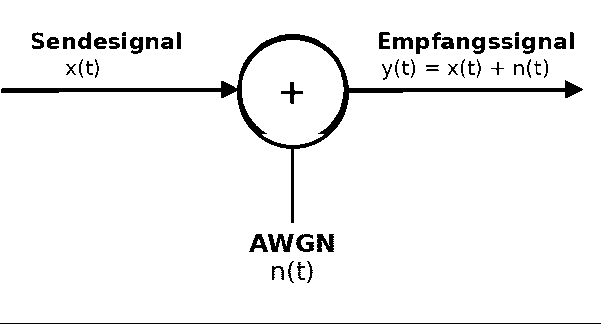

$
y(t) = x(t) + n(t)
$

Dabei ist:

- $x(t)$: Sendesignal
- $n(t)$: additive Störung / Rauschen
- $y(t)$: Empfangssignal

Die Störung wird als **AWGN** modelliert.

> **AWGN = Additive White Gaussian Noise**  
> (additives weißes gaußsches Rauschen)

Thermisches Rauschen entsteht durch die Bewegung der Elektronen und kann näherungsweise als AWGN beschrieben werden.

## 1. Vorbereitung

Import der benötigten Bibliotheken.

Für die interaktiven Regler wird `ipywidgets` verwendet. Falls die Widgets nicht angezeigt werden, muss `ipywidgets` zu installiert werden:

```bash
pip install ipywidgets
```

In [11]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from ipywidgets import interact, FloatSlider, IntSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets ist nicht installiert. Die statischen Beispiele funktionieren trotzdem.")

# Für reproduzierbare Beispiele
rng = np.random.default_rng(42)

# Grundeinstellungen für Diagramme
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

## 2. Kanalmodell

Das Kanalmodell besagt, dass ein Empfangssignal $y(t)$ durch Überlagerung des Sendesignals $x(t)$ mit einer Störung $n(t)$ entsteht:

$
y(t) = x(t) + n(t)
$



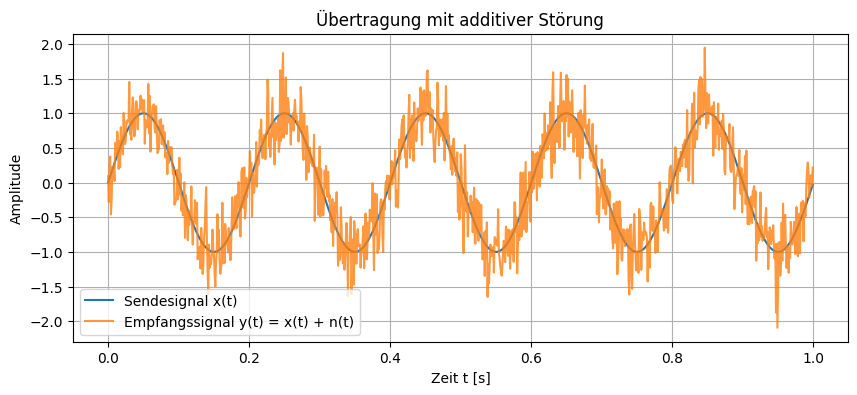

In [12]:
# Zeitachse
fs = 1000      # Abtastrate in Hz
T = 1.0        # Signaldauer in Sekunden
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Sendesignal: Sinus
f0 = 5         # Signalfrequenz in Hz
x = np.sin(2 * np.pi * f0 * t)

# Additive Störung
sigma = 0.3
n = rng.normal(loc=0, scale=sigma, size=len(t))

# Empfangssignal
y = x + n

plt.figure()
plt.plot(t, x, label="Sendesignal x(t)")
plt.plot(t, y, label="Empfangssignal y(t) = x(t) + n(t)", alpha=0.8)
plt.xlabel("Zeit t [s]")
plt.ylabel("Amplitude")
plt.title("Übertragung mit additiver Störung")
plt.legend()
plt.show()

## AWGN

Die Anteile der Abkürzung bedeuten:

- **Additive**: Rauschen wird zum Signal addiert.
- **White**: Rauschen besitzt idealisiert über alle Frequenzen eine konstante Leistungsdichte.
- **Gaussian**: Amplitudenwerte des Rauschens sind normalverteilt.
- **Noise**: Es handelt sich um eine zufällige Störung.

Das Rauschen wird wie folgt modelliert:

$
n(t) \sim \mathcal{N}(0,\sigma^2)
$

(Mittelwert 0 und Varianz $\sigma^2$.)

## 4. Gaussverteilung des Rauschens: Histogramm

Das Histogramm zeigt, dass kleine Amplituden häufig auftreten, große seltener.

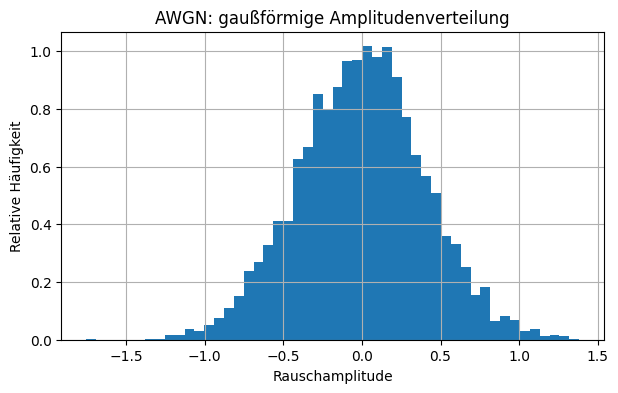

Mittelwert des Rauschens: -0.0017
Standardabweichung des Rauschens: 0.4023


In [13]:
sigma = 0.4
n = rng.normal(loc=0, scale=sigma, size=5000)

plt.figure(figsize=(7, 4))
plt.hist(n, bins=50, density=True)
plt.xlabel("Rauschamplitude")
plt.ylabel("Relative Häufigkeit")
plt.title("AWGN: gaußförmige Amplitudenverteilung")
plt.show()

print(f"Mittelwert des Rauschens: {np.mean(n):.4f}")
print(f"Standardabweichung des Rauschens: {np.std(n):.4f}")

## 5. White: Spektrum des Rauschens

Weißes Rauschen besitzt keine bevorzugte Frequenz. Die Rauschleistung ist über die betrachtete Bandbreite gleichmäßig verteilt. Die untenstehende Darstellung kann dies für einen stochastischen Prozess nicht leisten. Erst bei Mittelung über viele Stichproben kommt die gleichmäßige Verteilung zum Vorschein. 

In realen Systemen ist weißes Rauschen immer nur innerhalb einer betrachteten Bandbreite ein sinnvolles Modell.

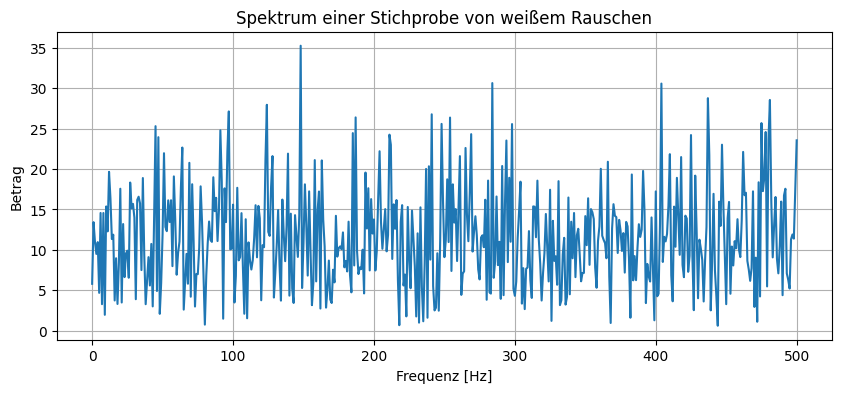

In [14]:
# Neues Rauschsignal
n = rng.normal(loc=0, scale=0.4, size=len(t))

freqs = np.fft.rfftfreq(len(n), d=1/fs)
N_fft = np.abs(np.fft.rfft(n))

plt.figure()
plt.plot(freqs, N_fft)
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Betrag")
plt.title("Spektrum einer Stichprobe von weißem Rauschen")
plt.show()

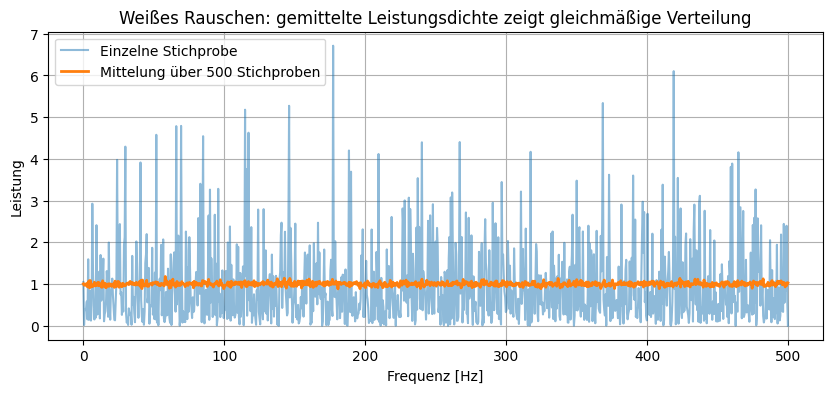

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
fs = 1000              # Abtastrate in Hz
N = 2048               # Anzahl Samples pro Rauschsignal
num_realizations = 500 # Anzahl der Mittelungen
sigma = 1.0            # Standardabweichung des AWGN

rng = np.random.default_rng(42)

# Frequenzachse
freqs = np.fft.rfftfreq(N, d=1/fs)

# Speicher für gemittelte Leistungsspektren
psd_sum = np.zeros(len(freqs))

# Viele unabhängige Rauschsignale erzeugen und Spektrum mitteln
for _ in range(num_realizations):
    n = rng.normal(loc=0, scale=sigma, size=N)
    
    # FFT
    N_fft = np.fft.rfft(n)
    
    # Periodogramm / Leistungsspektrum
    psd = (np.abs(N_fft) ** 2) / N
    
    # Aufsummieren
    psd_sum += psd

# Mittelwert über alle Realisierungen
psd_avg = psd_sum / num_realizations

# Zum Vergleich: eine einzelne Realisierung
n_single = rng.normal(loc=0, scale=sigma, size=N)
N_fft_single = np.fft.rfft(n_single)
psd_single = (np.abs(N_fft_single) ** 2) / N

# Plot
plt.figure(figsize=(10, 4))
plt.plot(freqs, psd_single, alpha=0.5, label="Einzelne Stichprobe")
plt.plot(freqs, psd_avg, linewidth=2, label=f"Mittelung über {num_realizations} Stichproben")
plt.xlabel("Frequenz [Hz]")
plt.ylabel("Leistung")
plt.title("Weißes Rauschen: gemittelte Leistungsdichte zeigt gleichmäßige Verteilung")
plt.legend()
plt.grid(True)
plt.show()

## 6. Interaktive Demo: Veränderliche Gewichtung der Amplituden

Mit dem Regler wird die Standardabweichung $\sigma$ des Rauschens verändert.

Resultat:

- kleines $\sigma$: Das Sendesignal bleibt gut erkennbar.
- großes $\sigma$: Das Signal wird zunehmend verdeckt.

In [16]:
def plot_noisy_signal(sigma=0.2):
    rng_local = np.random.default_rng(1)
    n = rng_local.normal(0, sigma, size=len(t))
    y = x + n

    plt.figure()
    plt.plot(t, x, label="Sendesignal x(t)")
    plt.plot(t, y, label="Empfangssignal y(t)", alpha=0.8)
    plt.xlabel("Zeit t [s]")
    plt.ylabel("Amplitude")
    plt.title(f"Additives Rauschen mit σ = {sigma:.2f}")
    plt.legend()
    plt.show()

if WIDGETS_AVAILABLE:
    interact(
        plot_noisy_signal,
        sigma=FloatSlider(value=0.2, min=0.0, max=1.5, step=0.05, description="σ")
    );
else:
    plot_noisy_signal(0.2)

interactive(children=(FloatSlider(value=0.2, description='σ', max=1.5, step=0.05), Output()), _dom_classes=('w…

## 7. Signal-Störleistungs-Verhältnis: SNR (Signal to Noise Ratio)

Die Qualität der Übertragung wird über das **Signal-Störleistungs-Verhältnis** beschrieben:

$
\mathrm{SNR} = \frac{P_\mathrm{Signal}}{P_\mathrm{Rauschen}}
$

Üblich ist die logarithmische Darstellung (in Dezibel):

$
\mathrm{SNR}_{\mathrm{dB}} = 10 \log_{10}
\left(
\frac{P_\mathrm{Signal}}{P_\mathrm{Rauschen}}
\right)
$

Je größer das SNR, desto stärker ist das Nutzsignal im Verhältnis zum Störsignal / Rauschen.

In [17]:
def calculate_snr_db(signal, noise):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

sigma = 0.3
n = rng.normal(0, sigma, size=len(t))
y = x + n

snr_db = calculate_snr_db(x, n)
print(f"SNR = {snr_db:.2f} dB")

SNR = 7.54 dB


## 8. Interaktive Demo: SNR verändern

Hier wird das Rauschen so gewählt, dass ein gewünschtes SNR entsteht.

In [18]:
def add_awgn_with_snr(signal, snr_db, seed=2):
    rng_local = np.random.default_rng(seed)
    signal_power = np.mean(signal**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise_std = np.sqrt(noise_power)
    noise = rng_local.normal(0, noise_std, size=len(signal))
    received = signal + noise
    return received, noise

def plot_snr_demo(snr_db=10):
    y, n = add_awgn_with_snr(x, snr_db)

    plt.figure()
    plt.plot(t, x, label="Sendesignal x(t)")
    plt.plot(t, y, label=f"Empfangssignal y(t), SNR = {snr_db:.1f} dB", alpha=0.8)
    plt.xlabel("Zeit t [s]")
    plt.ylabel("Amplitude")
    plt.title("Einfluss des Signal-Störleistungs-Verhältnisses")
    plt.legend()
    plt.show()

if WIDGETS_AVAILABLE:
    interact(
        plot_snr_demo,
        snr_db=FloatSlider(value=10, min=-10, max=30, step=1, description="SNR [dB]")
    );
else:
    plot_snr_demo(10)

interactive(children=(FloatSlider(value=10.0, description='SNR [dB]', max=30.0, min=-10.0, step=1.0), Output()…

## 9. Thermisches Rauschen

Thermisches Rauschen entsteht durch die ungeordnete Wärmebewegung von Ladungsträgern.

Für einen Widerstand kann die effektive thermische Rauschspannung näherungsweise beschrieben werden durch:

$
u_\mathrm{n,rms} = \sqrt{4 k_\mathrm{B} T R \Delta f}
$

mit:

- $k_\mathrm{B}$: Boltzmann-Konstante
- $T$: absolute Temperatur in Kelvin
- $R$: Widerstand
- $\Delta f$: betrachtete Bandbreite

Damit gilt:

- höhere Temperatur $\Rightarrow$ mehr Rauschen
- größerer Widerstand $\Rightarrow$ mehr Rauschen
- größere Bandbreite $\Rightarrow$ mehr Rauschen

In [19]:
k_B = 1.380649e-23  # Boltzmann-Konstante in J/K

def thermal_noise_voltage(T=300, R=1000, bandwidth=10000):
    u_n = np.sqrt(4 * k_B * T * R * bandwidth)
    print(f"T = {T:.0f} K")
    print(f"R = {R:.0f} Ω")
    print(f"Δf = {bandwidth:.0f} Hz")
    print(f"Thermische Rauschspannung u_n,rms = {u_n:.3e} V")
    print(f"Thermische Rauschspannung u_n,rms = {u_n * 1e6:.3f} µV")

if WIDGETS_AVAILABLE:
    interact(
        thermal_noise_voltage,
        T=FloatSlider(value=300, min=100, max=500, step=10, description="T [K]"),
        R=FloatSlider(value=1000, min=100, max=10000, step=100, description="R [Ω]"),
        bandwidth=FloatSlider(value=10000, min=100, max=100000, step=1000, description="Δf [Hz]")
    );
else:
    thermal_noise_voltage()

interactive(children=(FloatSlider(value=300.0, description='T [K]', max=500.0, min=100.0, step=10.0), FloatSli…

## 10. Thermisches Rauschen als AWGN im Kanalmodell

in vielen Fällen wird thermisches Rauschen als AWGN modelliert.

$
y(t) = x(t) + n(t),
$

wobei $n(t)$ näherungsweise ein additives weißes gaußsches Rauschen ist.


In [20]:
def plot_thermal_awgn(T=300, R=1000, bandwidth=10000):
    # Thermische Rauschspannung
    u_n = np.sqrt(4 * k_B * T * R * bandwidth)

    # Für die Visualisierung wird die Rauschspannung skaliert,
    # damit sie im Diagramm sichtbar wird.
    # In realen Schaltungen liegen die Werte oft im µV-Bereich.
    visualization_gain = 1e5
    sigma_vis = u_n * visualization_gain

    rng_local = np.random.default_rng(3)
    n_vis = rng_local.normal(0, sigma_vis, size=len(t))
    y_vis = x + n_vis

    plt.figure()
    plt.plot(t, x, label="Sendesignal x(t)")
    plt.plot(t, y_vis, label="Empfangssignal mit thermischem Rauschen", alpha=0.8)
    plt.xlabel("Zeit t [s]")
    plt.ylabel("Amplitude")
    plt.title("Thermisches Rauschen als AWGN-Modell")
    plt.legend()
    plt.show()

    print(f"Reale thermische Rauschspannung: {u_n * 1e6:.3f} µV")
    print(f"Für die Darstellung skaliert mit Faktor {visualization_gain:.0e}")

if WIDGETS_AVAILABLE:
    interact(
        plot_thermal_awgn,
        T=FloatSlider(value=300, min=100, max=500, step=10, description="T [K]"),
        R=FloatSlider(value=1000, min=100, max=10000, step=100, description="R [Ω]"),
        bandwidth=FloatSlider(value=10000, min=100, max=100000, step=1000, description="Δf [Hz]")
    );
else:
    plot_thermal_awgn()

interactive(children=(FloatSlider(value=300.0, description='T [K]', max=500.0, min=100.0, step=10.0), FloatSli…

## 12. Zusammenfassung

- Bei der Übertragung wird ein Signal durch Störungen beeinflusst.
- Einfaches Modell dafür ist additiv: $y(t)=x(t)+n(t)$.
- AWGN: $n(t)$ ist additives weißes gaußsches Rauschen.
- Thermisches Rauschen ist eine physikalische Ursache von Rauschen.
- In der Nachrichtentechnik wird thermisches Rauschen häufig als AWGN modelliert.
- Das SNR beschreibt, wie stark das Nutzsignal im Vergleich zum Rauschen ist.